In [244]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error


In [236]:
df= pd.read_csv("C:/Users/mickt/Downloads/Walmart_Store_sales(1).csv")
df_model = df[df["Weekly_Sales"].notnull()]
df_model.shape

(136, 8)

##  EDA

In [30]:
df.shape

(150, 8)

In [98]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,6.0,18-02-2011,1572117.54,NaN,59.61,3.045,214.777523,6.858
1,13.0,25-03-2011,1807545.43,0.0,42.38,3.435,128.616064,7.470
2,17.0,27-07-2012,NaN,0.0,NaN,NaN,130.719581,5.936
3,11.0,NaN,1244390.03,0.0,84.57,NaN,214.556497,7.346
4,6.0,28-05-2010,1644470.66,0.0,78.89,2.759,212.412888,7.092


In [11]:
df['Holiday_Flag'].value_counts()

Holiday_Flag
0.0    127
1.0     11
Name: count, dtype: int64

In [25]:
df["Store"].unique().argsort()

array([12, 13,  8,  4, 14,  0, 11,  9, 18, 19,  3, 17,  1,  7,  5, 16,  2,
       10, 15,  6])

In [17]:
df['Unemployment'].min()

5.143

In [16]:
df['Unemployment'].describe()

count    135.000000
mean       7.598430
std        1.577173
min        5.143000
25%        6.597500
50%        7.470000
75%        8.150000
max       14.313000
Name: Unemployment, dtype: float64

In [237]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y', errors='coerce')
start_date = df['Date'].min()
end_date = df['Date'].max()

print(start_date, end_date)

2010-02-05 00:00:00 2012-10-19 00:00:00


#### The data spans from the February 5th of 2010 to the October 19th of 2012

In [238]:
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day
df['dayofweek'] = df['Date'].dt.dayofweek
df.drop('Date', axis=1, inplace=True)


In [239]:
df = df[df["Weekly_Sales"].notnull()]

In [240]:
df.shape

(136, 11)

<Axes: xlabel='year', ylabel='Weekly_Sales'>

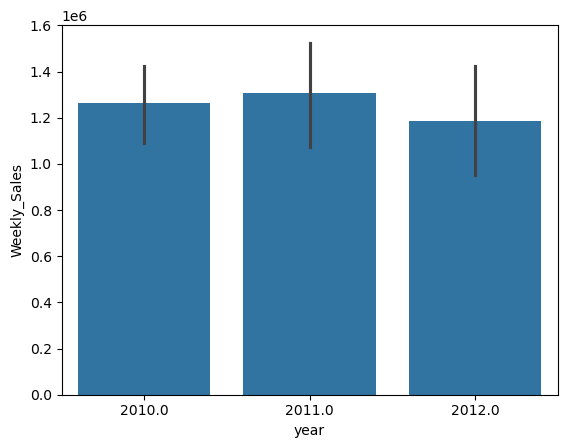

In [83]:
sns.barplot(x='year', y='Weekly_Sales', data=df)


<Axes: xlabel='month', ylabel='Weekly_Sales'>

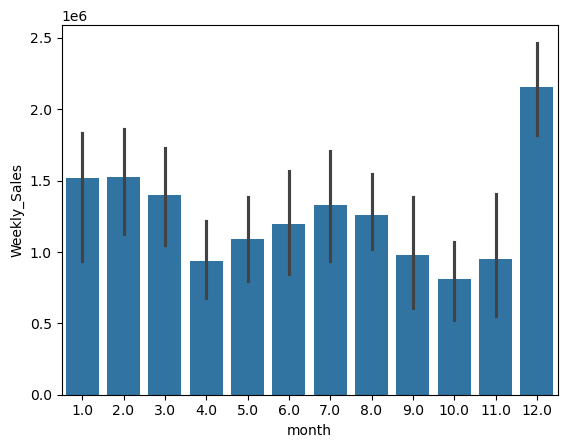

In [84]:
sns.barplot(x='month', y='Weekly_Sales', data=df)

<Axes: xlabel='Holiday_Flag', ylabel='Weekly_Sales'>

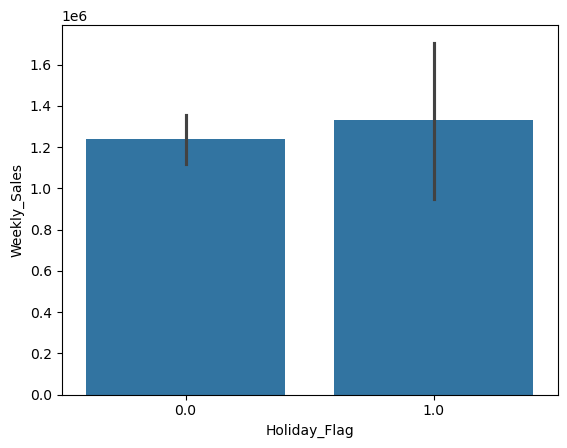

In [68]:
sns.barplot(x='Holiday_Flag', y='Weekly_Sales', data=df)



#### Minor differences were found between the averaged weekly sell and the holiday flag.
#### The variance was found to be larger in a holiday, which might be related to the holiday period.

## Preprocessing

In [241]:
df_model['Date'] = pd.to_datetime(df_model['Date'], format='%d-%m-%Y', errors='coerce')
df_model["Year"] = df_model['Date'].dt.year
df_model["Month"] = df_model['Date'].dt.month
df_model['Day'] = df_model['Date'].dt.day
df_model['DayOfWeek'] = df_model['Date'].dt.dayofweek
df_model.drop('Date', axis=1, inplace=True)

In [242]:
numerical_cols = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
for x in numerical_cols:
    x_mean = df_model[x].mean()
    x_std = df_model[x].std()
    df_model[x].drop(df_model[(df_model[x] >= x_mean - 3 * x_std) | (df_model[x] <= x_mean + 3 * x_std)].index, inplace=True)

## Model

### Ridge Regression

In [134]:
categorical_features = ['Store', 'Holiday_Flag']
numerical_features = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Day', 'DayOfWeek']

# Numerical pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean'))
])

# Categorical pipeline
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first'))
])

# Combine
preprocessor = ColumnTransformer([
    ('num', num_pipeline, numerical_features),
    ('cat', cat_pipeline, categorical_features)
])

In [135]:
model = Pipeline([
    ('preprocessing', preprocessor),
    ('regressor', LinearRegression())
])

In [147]:
X = df_model.drop(columns=['Weekly_Sales'])
y = df_model['Weekly_Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
print(f'R^2 Score: {r2}')
print(f'Mean Absolute Error: {mae}')
print(f'Root Mean Squared Error: {rmse}')

R^2 Score: 0.9391089500202593
Mean Absolute Error: 123864.33278029287
Root Mean Squared Error: 164182.94959841168


#### The model achieves an RMSE of €120,000 and an R² of ~ .94, meaning it explains 94% of the variance in weekly sales

In [ ]:
ridge_regularization_model = Pipeline([
    ('preprocessing', preprocessor),
    ('regressor', Ridge(alpha=.001115))
])
ridge_regularization_model.fit(X_train, y_train)
y_pred = ridge_regularization_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
print(f'R^2 Score: {r2}')
print(f'Mean Absolute Error: {mae}')
print(f'Root Mean Squared Error: {rmse}')


R^2 Score: 0.9390651783092233
Mean Absolute Error: 123874.39447922507
Root Mean Squared Error: 164241.95069604204


### Lasso/L1 Regularisation method.

In [228]:
# Numerical pipeline
num_pipeline_lasso = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())   # 🔥 CRITICAL for Lasso
])

# Categorical pipeline (unchanged)
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first'))
])

# ColumnTransformer
preprocessor2 = ColumnTransformer([
    ('num', num_pipeline_lasso, numerical_features),
    ('cat', cat_pipeline, categorical_features)
])

In [230]:
lasso_regularization_model2 = Pipeline([
    ('preprocessing', preprocessor2),
    ('regressor', Lasso(alpha=0.2, max_iter=10000))
])
lasso_regularization_model2.fit(X_train, y_train)
y_pred = lasso_regularization_model2.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
print(f'R^2 Score: {r2}')
print(f'Mean Absolute Error: {mae}')
print(f'Root Mean Squared Error: {rmse}')

R^2 Score: 0.9391087266948911
Mean Absolute Error: 123862.69074392809
Root Mean Squared Error: 164183.25067865304


In [225]:
lasso_regularization_model = Pipeline([
    ('preprocessing', preprocessor),    
    ('regressor', Lasso(alpha=0.1, max_iter=10000))
])
lasso_regularization_model.fit(X_train, y_train)
y_pred = lasso_regularization_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
print(f'R^2 Score: {r2}')
print(f'Mean Absolute Error: {mae}')
print(f'Root Mean Squared Error: {rmse}')

R^2 Score: 0.9391088384922772
Mean Absolute Error: 123863.51157752432
Root Mean Squared Error: 164183.09995700032


In [231]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'regressor__alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}
grid_search = GridSearchCV(estimator=lasso_regularization_model2, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)
best_alpha = grid_search.best_params_['regressor__alpha']
print(f'Best alpha: {best_alpha}')


Best alpha: 100


In [232]:
best_model = grid_search.best_estimator_
coef = best_model.named_steps['regressor'].coef_

import numpy as np
print("Number of non-zero coefficients:", np.sum(coef != 0))
print("Total coefficients:", len(coef))

Number of non-zero coefficients: 26
Total coefficients: 28


#### Ridge regression did not improve performance with tuning of coefficient alpha, suggesting limited overfitting in the baseline model. However, Lasso regression enabled feature selection by shrinking some coefficients to zero, helping identify the most influential variables.

## Feature Evaluation

In [233]:
regressor = regularization_model.named_steps['regressor']
coefficients = regressor.coef_  # array of length = number of transformed features

In [187]:
# Access the ColumnTransformer
preprocessor = regularization_model.named_steps['preprocessing']

# Numerical features (passed through)
num_features = numerical_features  # same as your list used in the preprocessor

# Categorical features (after OneHotEncoder)
cat_features = preprocessor.named_transformers_['cat'] \
                .named_steps['encoder'].get_feature_names_out(categorical_features)

# Combine all
all_features = list(num_features) + list(cat_features)

In [189]:
import pandas as pd

coef_df = pd.DataFrame({
    'Feature': all_features,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', key=abs, ascending=False)

coef_df

,Feature,Coefficient
11,Store_5.0,-1.283843e+06
9,Store_3.0,-1.160580e+06
15,Store_9.0,-1.083646e+06
22,Store_16.0,-1.047946e+06
13,Store_7.0,-9.860798e+05
14,Store_8.0,-7.280440e+05
21,Store_15.0,-7.028797e+05
20,Store_14.0,6.490545e+05
10,Store_4.0,6.395313e+05
23,Store_17.0,-5.855863e+05


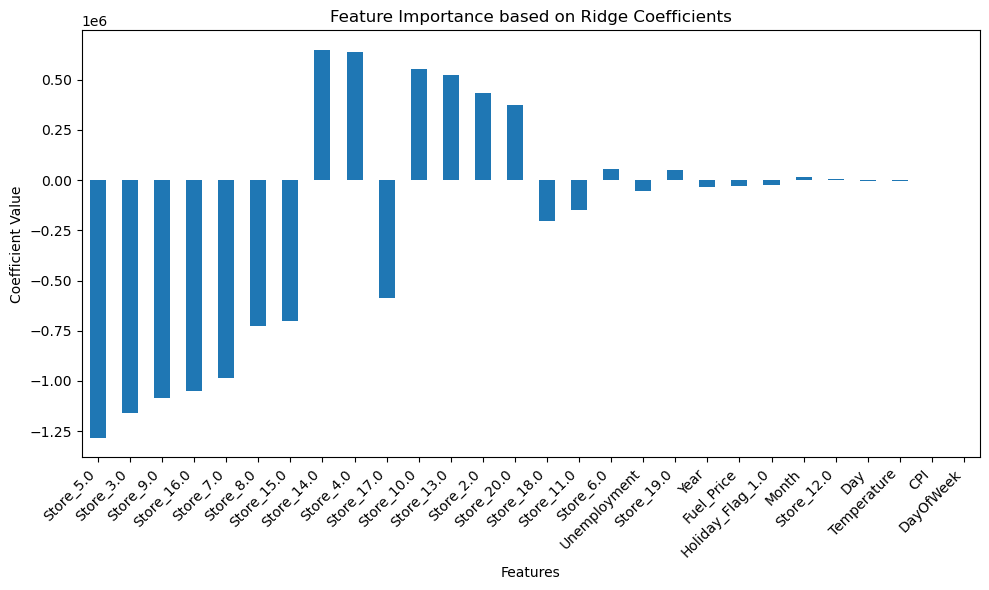

In [196]:
feature_importance = coef_df.set_index('Feature')['Coefficient']
plt.figure(figsize=(10, 6))
feature_importance.plot(kind='bar')
plt.title('Feature Importance based on Ridge Coefficients')
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### While DayOfWeek and CPI are included in the model, their coefficients are very small (or zero), meaning any effect they have on weekly sales is within the margin of error and not practically significant. The strongest predictors remains the Store identity, Holiday_Flag, Fuel_Price, and Unemployment.”